# - DSC 550: Week 12
- Final Project - Milestones 1-4
- Martin Hoehler
- 3/2/25

## Final Project - Predicting a Country’s Banking Z-Score

### Milestone 1

In the banking industry, the financial health of a bank is called the “z-score”.  The higher the z-score, the lower the risk is for the bank to fail.  The World Bank Group (https://www.worldbank.org/ext/en/home) has published a country-level report on z-scores.  With this report, banking organizations can get an idea of whether opening a bank in a country would be a safe investment.

The World Bank Group also publishes other studies about the economies of individual countries, where you can find “World Development Indicator” statistics like the % of females in a country with a financial account of some type, or the extent to which businesses disclose data to the public.  It would be theoretically possible to attempt to build a model that takes each country’s specific survey results and attempt to predict a z-score.

With only 200 countries in the data, the set will be small for training.  However, the data is collected in multiple years, giving us multiple lines per country.  Also, we can simplify our design to predict above or below a specified z-score.
For our first Milestone, I have created a sample CSV of one line per country with the z-scores for 2021.  We will do our EDA with those values to determine the best way to build and clean a larger data set for Milestone 2.

With a model like this, a bank could look at a demographic of an area and use the development indicators to predict the Z-score of a bank that would open there.  There is an ethical concern that I can already imagine. This model could be used to avoid development in already under-banked communities in poorer areas.  But it could also be used to understand how the financial stability of an area is linked to other societal measures and indicators.

Sources:
Bank Z-Scores: https://databank.worldbank.org/source/global-financial-development/Series/GFDD.SI.01

Country World Development Indicators: https://databank.worldbank.org/source/world-development-indicators#


In [1]:
# Import text file

import pandas as pd
import numpy as np


bank_EDA = pd.read_csv('Sample_bank_Country_data.csv', header=0)
bank_EDA.head()


,Row Labels,Z Score Bank,Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+),"Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, poorest 40% (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, primary education or less (% of population ages 15+)","Account ownership at a financial institution or with a mobile-money-service provider, young adults (% of population ages 15-24)","Average working hours of children, working only, ages 7-14 (hours per week)",Bribery incidence (% of firms experiencing at least one bribe payment request),Business extent of disclosure index (0=less disclosure to 10=more disclosure),"Central government debt, total (% of GDP)","Compulsory education, duration (years)",Control of Corruption: Percentile Rank,Coverage of social insurance programs in poorest quintile (% of population),Coverage of social safety net programs (% of population),"Survival to age 65, female (% of cohort)",Technicians in R&D (per million people),Time required to start a business (days)
0,Afghanistan,24.915610,9.65,4.70,14.79,5.86,5.18,7.55,0,0.0,8.0,0.000000,9,13.679245,0.000000,0.000000,69.906777,0,8.5
1,Angola,15.548360,0.00,0.00,0.00,0.00,0.00,0.00,0,0.0,4.0,0.000000,10,30.188679,0.000000,0.000000,68.636516,0,36.0
2,Argentina,9.083421,71.63,73.75,69.56,65.23,57.10,75.37,0,0.0,7.0,0.000000,14,52.857143,21.880785,41.398729,86.163347,0,11.5
3,Australia,14.145260,99.32,100.00,98.59,98.30,86.48,100.00,0,0.0,8.0,70.010912,11,95.754715,0.000000,0.000000,93.408547,0,2.0
4,Austria,30.906530,99.95,100.00,99.90,100.00,100.00,100.00,0,1.3,5.0,100.056790,13,90.952377,0.000000,0.000000,93.266368,0,21.0


In [2]:
# Let's check the size of the dataset.

bank_EDA.shape

(128, 19)

In [3]:
#  To confirm that all rows are populated in this data set, we'll count NaN entries.
nan_counts = bank_EDA.isna().sum()
print(nan_counts)

Row Labels                                                                                                                                    0
Z Score Bank                                                                                                                                  0
Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)                               0
Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)                       0
Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)                         0
Account ownership at a financial institution or with a mobile-money-service provider, poorest 40% (% of population ages 15+)                  0
Account ownership at a financial institution or with a mobile-money-service provider, primary education or less (% of population ages 15

In [4]:
#  Now we'll confirm what data types we're working with.
bank_EDA.dtypes

Row Labels                                                                                                                                     object
Z Score Bank                                                                                                                                  float64
Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)                               float64
Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)                       float64
Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)                         float64
Account ownership at a financial institution or with a mobile-money-service provider, poorest 40% (% of population ages 15+)                  float64
Account ownership at a financial institution or with a mobile-money-service provider, primary educat

It appears as all the fields you'd expect to be a number have a numeric type.  So we can begin some exploratory analysis of the fields.  The first I'd like to explore are "Job_Role" and "Salary" to see how they are spread out.

We'll use a series of boxplots to check to see if there's much variety in salary based on Job Role.
Source: https://www.analyticsvidhya.com/blog/2021/08/understanding-bar-plots-in-python-beginners-guide-to-data-visualization/

<function matplotlib.pyplot.show(close=None, block=None)>

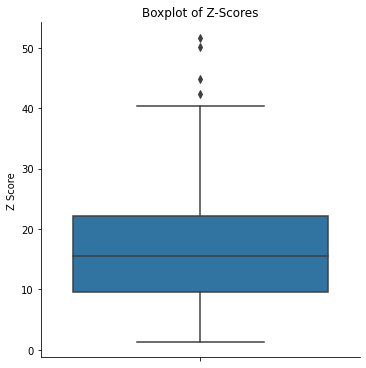

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

salary_box = sns.catplot(y = "Z Score Bank", kind="box", data = bank_EDA)
plt.ylabel('Z Score')
plt.title('Boxplot of Z-Scores')

plt.show

This shows that the about half of Z-scores across the countries sit in the 10-22 range, and that we have some outlier countries with very large z scores, some above 40.

Next, we'll look at correlations between the Z-Scores and the development indicators.  First, we have a scatterplot of the relationship between a country's bank Z-Score and the percent of women who have financial accounts.

Text(0.5, 1.0, 'Scatterplot of Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+) vs Z Score Bank')

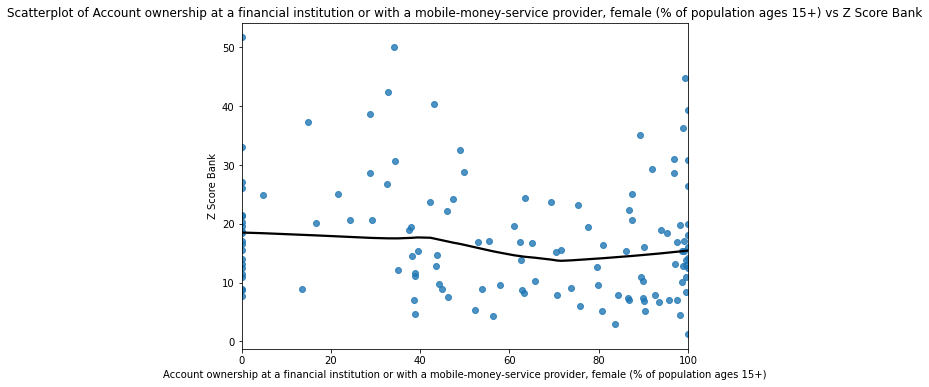

In [6]:
# 4. Plot Female Financial Accounts vs Z-Score

x_col = 'Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)' 
y_col = 'Z Score Bank'


plt.figure(figsize=(8, 6)) 
sns.regplot(x=bank_EDA[x_col], y=bank_EDA[y_col], lowess=True, ci=False, line_kws={'color': 'black'}) 
plt.xlabel(x_col) 
plt.ylabel(y_col) 
plt.title(f'Scatterplot of {x_col} vs {y_col}')

There does not seem to be a very strong relationship here.  Perhaps some of the other financial account questions might be more predictive.  As it is, it appears that there are several countries with high Z scores that don't have particularly open banking environments for women.

From a data perpective, we can also see a lot of countries that don't have a value for this.  We will want to exclude zero values from our model in the data preparation phase.

Text(0.5, 1.0, 'Scatterplot of Survival to age 65, female (% of cohort) vs Z Score Bank')

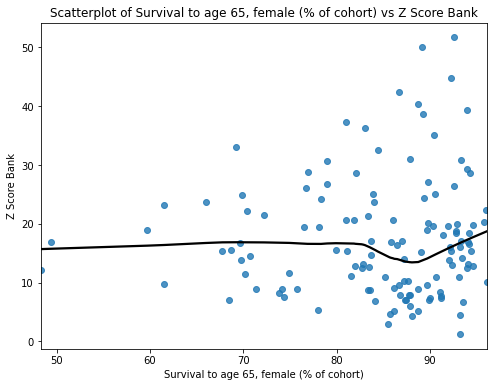

In [7]:
# 4. Plot Female survival to 65 vs Z score

x_col = 'Survival to age 65, female (% of cohort)' 
y_col = 'Z Score Bank'


plt.figure(figsize=(8, 6)) 
sns.regplot(x=bank_EDA[x_col], y=bank_EDA[y_col], lowess=True, ci=False, line_kws={'color': 'black'}) 
plt.xlabel(x_col) 
plt.ylabel(y_col) 
plt.title(f'Scatterplot of {x_col} vs {y_col}')

In this graph, we don't see much of a relationship between age expectancy of women and the Z-score.  The data-set has additional life expectancy measures that might work better.

Text(0.5, 1.0, 'Scatterplot of Time required to start a business (days) vs Z Score Bank')

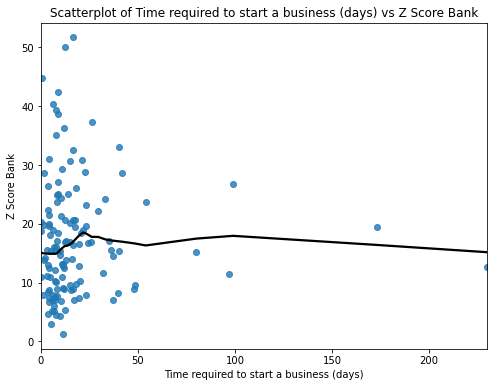

In [8]:
# 4. Plot time required to start a business vs Z score

x_col = 'Time required to start a business (days)' 
y_col = 'Z Score Bank'


plt.figure(figsize=(8, 6)) 
sns.regplot(x=bank_EDA[x_col], y=bank_EDA[y_col], lowess=True, ci=False, line_kws={'color': 'black'}) 
plt.xlabel(x_col) 
plt.ylabel(y_col) 
plt.title(f'Scatterplot of {x_col} vs {y_col}')

In this graph, we can see that there does appear to be an increasing relationship at the beginning.  Countries that allow a business to start in very few days may indicate that their regulatory environment is not robust enough to support a healthy business enviroment.  By grouping this development indicator into buckets, we may be able to find a useful predictor for Z-score.

Text(0.5, 1.0, 'Scatterplot of Business extent of disclosure index (0=less disclosure to 10=more disclosure) vs Z Score Bank')

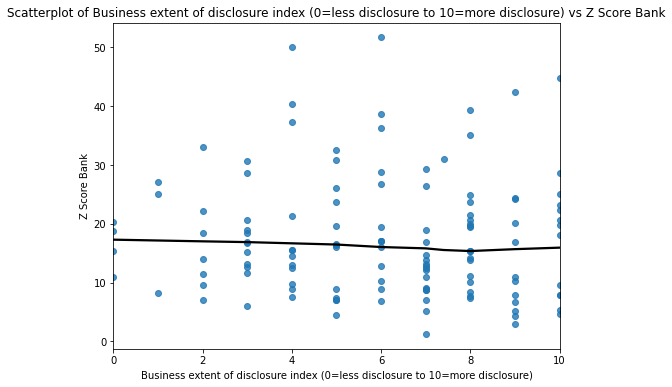

In [9]:
# 4. Plot business disclosuer index

x_col = 'Business extent of disclosure index (0=less disclosure to 10=more disclosure)' 
y_col = 'Z Score Bank'


plt.figure(figsize=(8, 6)) 
sns.regplot(x=bank_EDA[x_col], y=bank_EDA[y_col], lowess=True, ci=False, line_kws={'color': 'black'}) 
plt.xlabel(x_col) 
plt.ylabel(y_col) 
plt.title(f'Scatterplot of {x_col} vs {y_col}')

In this scatterplot, we can see very little relationship between Z score and the amount of disclosure that businesses are required.  I'd be interested in checking a correlation coefficient on some of these, though, to see if there are any relationships that aren't quite as visible to graphical analysis.

For the next milestone, I plan to refine the data set to help discover the features with the most predictive power.  Additionally, this snapshot is taking place in 2021, which was a stressful time in the banking sector, due to the pandemic.  With additional years of data added in, we may be able to find better correlations.

## Milestone 2: Data Preparation

For this milestone, we will pivot slightly from the direction we were taking in Milestone 1.  After reading about the dangers of data snooping, I realized that I was veering into that direction above.  The World Bank Group's data base has a very large list of features, and I was approaching a large pack of them, and looking for the ones that looked most promising.

Instead, I'm going to focus my hypothesis a bit, by limiting the features to a subset category called "Financial Institutions: Access".  These are features that measure specifically how much access a country has to financial products.  With this new focus, I can answer a more targeted question:  Does a country's access to financial institutions predict the vulnerability of its banking system?  

In my industry, a major concern is determining areas of our footprint in which the population is under-served by financial services.  These 'banking deserts" are primarily poorer areas, where individuals do not tend to have a place to deposit pay checks or save for retirement.  Instead, they can be preyed upon by predatory lending business, like check-cashing/payday loan centers that charge exorbidant fees.  This model could potentially make the case for increasing investment in underserved locations, if it demonstrates that improved access to financial institutions predicts a higher Z-score and better banking stability.

In [10]:
#  Bring in a new dataset, with Z-Score, and the series of "Financial Institutions: Access" features (Series Code "GFDD.AI").

bank_Prep = pd.read_csv('DataBank Data 2-1-25.csv', header=0)

bank_Prep.head()



,Series Name,Series Code,Country Name,Country Code,1997 [YR1997],1998 [YR1998],1999 [YR1999],2000 [YR2000],2001 [YR2001],2002 [YR2002],...,2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021]
0,Bank Z-score,GFDD.SI.01,East Asia & Pacific (IDA total),DEA,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
1,Bank Z-score,GFDD.SI.01,Europe & Central Asia (IDA total),DEC,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
2,Bank Z-score,GFDD.SI.01,IBRD only,IBD,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
3,Bank Z-score,GFDD.SI.01,IDA total,IDA,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
4,Bank Z-score,GFDD.SI.01,Latin America & Caribbean (IDA total),DLA,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..


In [11]:
#  Check the Tail for footnotes:

bank_Prep.tail()


,Series Name,Series Code,Country Name,Country Code,1997 [YR1997],1998 [YR1998],1999 [YR1999],2000 [YR2000],2001 [YR2001],2002 [YR2002],...,2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021]
8325,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8328,Data from database: Global Financial Development,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8329,Last Updated: 09/23/2022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
# Delete any rows that don't have a value in 'Series Code'.  This will remove the footnote lines.

bank_Prep_clean = bank_Prep.dropna(subset=['Series Code'])

# Remove columns 1997, 1998, 1999 - Z Score was not recorded for any country in those years.
bank_Prep_clean = bank_Prep_clean.drop(['1997 [YR1997]','1998 [YR1998]','1999 [YR1999]'], axis = 1)

# Replace empty values: switch from '..' to NaN
bank_Prep_clean.replace("..", np.nan, inplace = True)

bank_Prep_clean.tail()

,Series Name,Series Code,Country Name,Country Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],...,2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021]
8320,Account at a formal financial institution (% a...,GFDD.AI.05,Virgin Islands (U.S.),VIR,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8321,Account at a formal financial institution (% a...,GFDD.AI.05,West Bank and Gaza,PSE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,24.24381,NaN,NaN,25.02218,NaN,NaN,NaN,33.18041
8322,Account at a formal financial institution (% a...,GFDD.AI.05,"Yemen, Rep.",YEM,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,6.448482,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8323,Account at a formal financial institution (% a...,GFDD.AI.05,Zambia,ZMB,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,31.29242,NaN,NaN,35.83004,NaN,NaN,NaN,23.84446
8324,Account at a formal financial institution (% a...,GFDD.AI.05,Zimbabwe,ZWE,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,17.18949,NaN,NaN,28.17998,NaN,NaN,NaN,29.24969


### Interpolate values
Surveys were not performed for every year for every question, but it's a reasonable approximation to estimate that between two surveys, the value would change linearly from one value to the next.  So we will use interpolate() to fill in NaN values in between surveys.
 - Source: https://www.geeksforgeeks.org/pandas-dataframe-interpolate/

In [13]:
bank_interp = bank_Prep_clean.copy()
bank_interp.iloc[:, 4:] = bank_interp.iloc[:, 4:].astype(float)
bank_interp.iloc[:, 4:] = bank_interp.iloc[:, 4:].interpolate(method='linear', axis=1)
bank_interp.to_csv('bank_interp.csv')

In [14]:
# Use pd.melt() to 'un-pivot' the years columns into a long table form.
# Resource: https://www.geeksforgeeks.org/python-pandas-melt/

pivot1 = pd.melt(bank_interp, id_vars = ['Series Name', 'Series Code', 'Country Name', 'Country Code'],
                value_vars = ['2000 [YR2000]','2001 [YR2001]',
                              '2002 [YR2002]','2003 [YR2003]','2004 [YR2004]','2005 [YR2005]','2006 [YR2006]',
                              '2007 [YR2007]','2008 [YR2008]','2009 [YR2009]','2010 [YR2010]','2011 [YR2011]',
                              '2012 [YR2012]','2013 [YR2013]','2014 [YR2014]','2015 [YR2015]','2016 [YR2016]',
                              '2017 [YR2017]','2018 [YR2018]','2019 [YR2019]','2020 [YR2020]','2021 [YR2021]'],
                var_name = 'Year')

pivot1.head()

,Series Name,Series Code,Country Name,Country Code,Year,value
0,Bank Z-score,GFDD.SI.01,East Asia & Pacific (IDA total),DEA,2000 [YR2000],NaN
1,Bank Z-score,GFDD.SI.01,Europe & Central Asia (IDA total),DEC,2000 [YR2000],NaN
2,Bank Z-score,GFDD.SI.01,IBRD only,IBD,2000 [YR2000],NaN
3,Bank Z-score,GFDD.SI.01,IDA total,IDA,2000 [YR2000],NaN
4,Bank Z-score,GFDD.SI.01,Latin America & Caribbean (IDA total),DLA,2000 [YR2000],NaN


In [15]:
#  At this point, we'll clean up our columns by combining Country Code and Year into one field.  
# --- We can also drop the larger text versions of the fields (Series Name, Country Name) and keep the code versions instead.
# ----- This will decrease the size of the dataset, and potentially make the model run more efficiently.

pivot1['Country_Year'] = pivot1['Country Code']+ pivot1['Year'].str[4:]

pivot1_small = pivot1.drop(['Series Name', 'Country Name', 'Country Code', 'Year'], axis = 1)

pivot1.to_csv('bank_pivot_1.csv')
pivot1_small.to_csv('bank_pivot_small.csv')

In [16]:
# Use pivot() to pivot the "Series Name".  This will give us a column for each question.
# Resource: https://www.influxdata.com/blog/pandas-pivot-tutorial

pivot2 = pivot1_small.pivot(index= ['Country_Year'], columns = 'Series Code', values = 'value')
pivot2.shape

(4950, 37)

In [17]:
pivot2.to_csv('bank_pivot_2.csv')

In [18]:
# Delete rows where the target (Z-score) is NaN.  (A row with no target value is not useful for training.)

final_clean1 = pivot2.dropna(subset=['GFDD.SI.01'])
final_clean1.head()



Series Code,GFDD.AI.01,GFDD.AI.02,GFDD.AI.03,GFDD.AI.04,GFDD.AI.05,GFDD.AI.06,GFDD.AI.07,GFDD.AI.08,GFDD.AI.09,GFDD.AI.10,...,GFDD.AI.28,GFDD.AI.29,GFDD.AI.30,GFDD.AI.31,GFDD.AI.32,GFDD.AI.33,GFDD.AI.34,GFDD.AI.35,GFDD.AI.36,GFDD.SI.01
Country_Year,,,,,,,,,,,,,,,,,,,,,
AFG [YR2006],NaN,0.923777,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.99729
AFG [YR2007],NaN,1.237723,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,31.96604
AFG [YR2008],36.402495,1.477083,3.400000,2.300000,NaN,NaN,NaN,NaN,NaN,NaN,...,1.4,2.500000,77.800000,253.5,49.900000,NaN,0.700000,1.000000,36.600000,19.94573
AFG [YR2009],87.487134,2.225369,3.683333,2.516667,NaN,NaN,NaN,NaN,NaN,NaN,...,1.5,2.733333,76.616667,253.5,49.083333,NaN,0.833333,1.033333,38.433333,26.69275
AFG [YR2010],105.885740,2.386860,3.966667,2.733333,NaN,NaN,NaN,NaN,NaN,NaN,...,1.6,2.966667,75.433333,253.5,48.266667,NaN,0.966667,1.066667,40.266667,24.95099


In [19]:
# Delete rows where all the features are NaN.  (A row with no features is not useful for training either.)
# --- First, we'll need to define the 36 feature rows, which are all the rows, excluding the "Series Code" and the final column.

feature_columns = final_clean1.columns[1:-1]

final_clean2 = final_clean1.dropna(subset = feature_columns, how='all')


final_clean2.to_csv('final_clean_2.csv')


In [20]:
final_clean2.shape

(2846, 37)

#### Exploration

The dataset has now been cleaned so that every row has one target and at least one feature.  We still have 2846 rows to work with.  

Now it is time to do another round of data exploration, similar to Milestone 1, to see if there are signs of correlations with the features and the target.  First, we'll look at the features that have the most information.

In [21]:
final_clean2.count()

Series Code
GFDD.AI.01    1374
GFDD.AI.02    2763
GFDD.AI.03    1619
GFDD.AI.04    1619
GFDD.AI.05    1602
GFDD.AI.06    1602
GFDD.AI.07    1602
GFDD.AI.08    1148
GFDD.AI.09     669
GFDD.AI.10     870
GFDD.AI.11    1102
GFDD.AI.12    1149
GFDD.AI.13    1220
GFDD.AI.14    1149
GFDD.AI.15    1582
GFDD.AI.16    1510
GFDD.AI.17    1571
GFDD.AI.18    1602
GFDD.AI.19    1327
GFDD.AI.20    1602
GFDD.AI.21    1602
GFDD.AI.22    1149
GFDD.AI.23    1120
GFDD.AI.24     742
GFDD.AI.25    2669
GFDD.AI.26    1095
GFDD.AI.27    1612
GFDD.AI.28    1625
GFDD.AI.29    1516
GFDD.AI.30    1619
GFDD.AI.31    1594
GFDD.AI.32    1614
GFDD.AI.33     808
GFDD.AI.34    1625
GFDD.AI.35    1516
GFDD.AI.36    1625
GFDD.SI.01    2846
dtype: int64

Feature "GFDD.AI.02" has a lot of values.  That corresponds with the "# of bank branches per 100,000 adults".  We'll see if we can visually see a correlation with Z-score.

Text(0.5, 1.0, 'Scatterplot of Bank branches per 100,000 adults vs Bank Z-score')

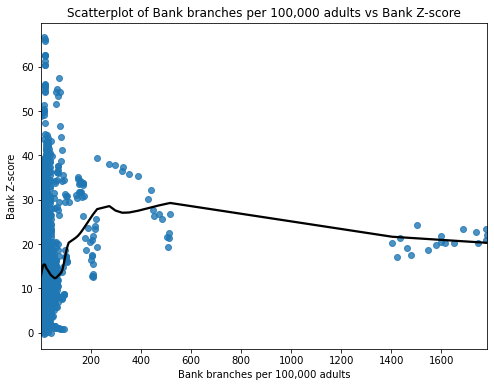

In [22]:
# Plot Bank Branches vs Z-Score

x_col = 'GFDD.AI.02' 
y_col = 'GFDD.SI.01'


plt.figure(figsize=(8, 6)) 
sns.regplot(x=final_clean2[x_col], y=final_clean2[y_col], lowess=True, ci=False, line_kws={'color': 'black'}) 
plt.xlabel("Bank branches per 100,000 adults") 
plt.ylabel("Bank Z-score") 
plt.title(f'Scatterplot of Bank branches per 100,000 adults vs Bank Z-score')

<function matplotlib.pyplot.show(close=None, block=None)>

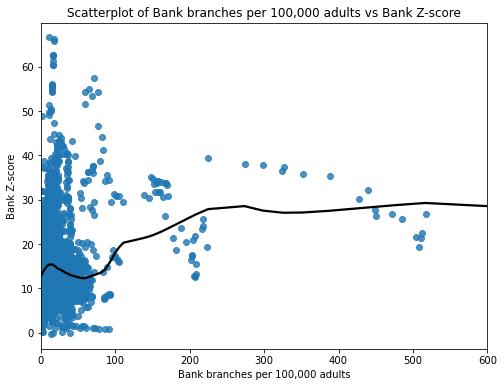

In [23]:
#  It looks like there's a positive relationship in the lower values, with diminishing returns after 600 branches.
# --- We'll limit it to a max of 600 to see how that

plt.figure(figsize=(8, 6)) 
sns.regplot(x=final_clean2[x_col], y=final_clean2[y_col], lowess=True, ci=False, line_kws={'color': 'black'}) 
plt.xlabel("Bank branches per 100,000 adults") 
plt.ylabel("Bank Z-score") 
plt.title(f'Scatterplot of Bank branches per 100,000 adults vs Bank Z-score')
plt.xlim(0,600)
plt.show

It does appear that there is a relationship between having branches open, and a healthier Z-score for a country.  The next feature with a lot of information is the number of ATMs that the population can access.

Text(0.5, 1.0, 'Scatterplot of ATMs per 100,000 adults vs Bank Z-score')

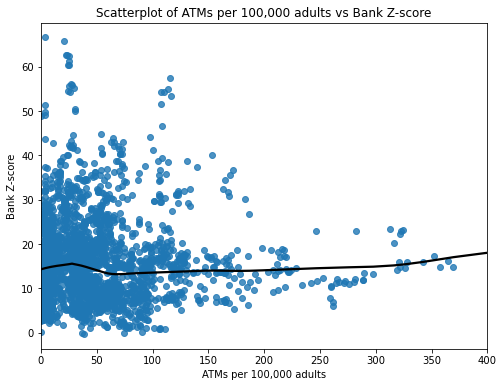

In [24]:
# Plot ATMs vs Z-Score
# --- Similar to bank branches, we'll limit the upper end.

x_col = 'GFDD.AI.25' 
y_col = 'GFDD.SI.01'


plt.figure(figsize=(8, 6)) 
sns.regplot(x=final_clean2[x_col], y=final_clean2[y_col], lowess=True, ci=False, line_kws={'color': 'black'}) 
plt.xlabel("ATMs per 100,000 adults") 
plt.ylabel("Bank Z-score") 
plt.xlim(0,400)
plt.title(f'Scatterplot of ATMs per 100,000 adults vs Bank Z-score')

Both the number of bank branches and the number of ATMs seem to give a good indication of correlation.  These might be good potential features, but they might also be redundant.  Places that have a lot of bank branches are also likely to have a lot of ATMs.  (Each bank likely has an ATM, for instance.) So I would not be surprised if the model picked one of these features for the model and not the other.

Text(0.5, 1.0, 'Scatterplot of Investments Financed by Banks (%) vs Bank Z-score')

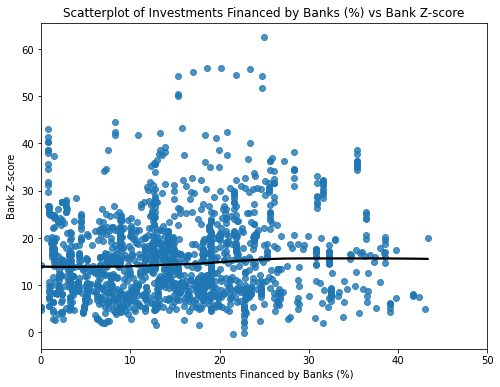

In [25]:
# Investments financed by banks vs Z-Score
# --- Similar to bank branches, we'll limit the upper end.

x_col = 'GFDD.AI.34' 
y_col = 'GFDD.SI.01'


plt.figure(figsize=(8, 6)) 
sns.regplot(x=final_clean2[x_col], y=final_clean2[y_col], lowess=True, ci=False, line_kws={'color': 'black'}) 
plt.xlabel("Investments Financed by Banks (%)") 
plt.ylabel("Bank Z-score") 
plt.xlim(0,50)
plt.title(f'Scatterplot of Investments Financed by Banks (%) vs Bank Z-score')

This next measure, "Investments Financed By Banks" shows how active the bank system is in supporting the local ecconomy.  This is a slightly different measure than just the brick and mortar presence of branches and ATMs.  So the slight upward slope of the regression line indicates that this might be a potentially useful feature that would bring different information to the model.

Text(0.5, 1.0, 'Scatterplot of Loan from family or friends in the past year (% age 15+) vs Bank Z-score')

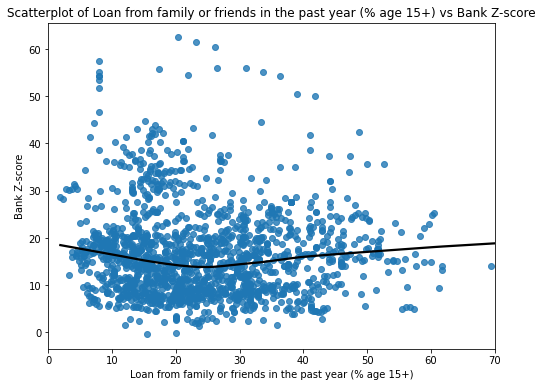

In [26]:
# Investments financed by banks vs Z-Score
# --- Similar to bank branches, we'll limit the upper end.

x_col = 'GFDD.AI.18' 
y_col = 'GFDD.SI.01'


plt.figure(figsize=(8, 6)) 
sns.regplot(x=final_clean2[x_col], y=final_clean2[y_col], lowess=True, ci=False, line_kws={'color': 'black'}) 
plt.xlabel("Loan from family or friends in the past year (% age 15+)") 
plt.ylabel("Bank Z-score") 
plt.xlim(0,70)
plt.title(f'Scatterplot of Loan from family or friends in the past year (% age 15+) vs Bank Z-score')

This feature has an interesting regression line.  It appears that up to a point, the more people that are getting loans from family, the lower the country's Bank Z-score, but then it rebounds and rises.  It will be interesting to see if this feature is used in the model, and if so, how.

### Conclusion: Milestone 2

By refocussing our hypothesis from Milestone 1, and focusing our features on those that describe the access to financial institutions in the country, it looks as though we are finding some promising correlations.  I feel better that this set of features represents a wide array of measurements that come at the topic of Access from different angles, and can potentially produce a robust model.

#### Upcoming Challenges
##### Empty Data
Even with interpolation, there are still a lot of empty data values.  We will have to find the best model to handle that.  After some preliminary research, I've found that tree models may work well, because "NaN" can be one of the options on the branches.  Also, there are some gradient boosting tools that could help.
##### Scaling
The features contain different scales.  Some are "Counts out of 100,000" and some are percentages.  We will likely need at least some Min/Max scaling on the features.
##### Deciding on the prediction criteria
Do we want the model to predict a Z-score, or do we want it to predict "above/below" a threshold?  With only 2846 training rows, this decision will likely have an impact on the overall accuracy of the model.
##### Feature Selection
We've already reasoned that some of these questions may be redundant.  We will want to attempt to reduce the number of features and select the ones that have the most predictive power independent of the other selected features.

In [27]:
final_clean2.to_csv('final_clean2.csv')

## Milestone 3: Model Building and Evaluation

Building on our research and conclusions from milestone 2, we will proceed with a tree model.  

### Dummy Rows to Highlight NaN
As noted, we have a lot of NaN values in our data.  However, the actual fact that NaN values exist might be valuable data for a model.  If a country was not tested for a particular feature, it may indicate something about the country's banking environment.  

So first, we will create dummy variables where each row will be called out if a NaN exists.

Resource: https://stackoverflow.com/questions/78405251/create-dummy-for-missing-values-for-variable-in-python

In [28]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Create dummy variables to call out NaN values for a feature.

Dummy_bank = final_clean2.copy()

for column in Dummy_bank.columns:
    Dummy_bank[f'{column}_is_nan'] = Dummy_bank[column].isna().astype(int)

In [29]:
Dummy_bank.to_csv('Dummy_bank.csv')

### KNN Imputation
We'll now use KNN Imputation to fill in the NaN values that remain.  I'm attempting KNN because I'd like it to take into account similar rows, instead of just using a mean of all the countries.  

The KNN Imputer does not like non-numerical columns, so I will drop the "Country_Year" column from the data, and then add it back in after the imputer runs.  We will also remove the GFDD.SI.01 column before the imputing step, because we don't want the target value to influence the KNN imputation.  We won't have that information in the future to help predict NaN values, so we shouldn't use it for training our model.

Resource:  "Machine Learning with Python Cookbook" (pg 86)



In [30]:
#  KNN Imputation

knn_imputer = KNNImputer(n_neighbors = 5)

#  Remove Row label column ("Country_Year")
# --- The KNN imputer will drop non-numerical columns.
#  Also remove the Target Column: GFDD.SI.01
Dummy_bank.reset_index(inplace=True)
Country_Year = Dummy_bank['Country_Year']
target = Dummy_bank['GFDD.SI.01']
data_without_country_year = Dummy_bank.drop(['Country_Year', 'GFDD.SI.01'], axis=1)

# Run Imputer
Bank_imputed = pd.DataFrame(knn_imputer.fit_transform(data_without_country_year), columns = data_without_country_year.columns)

# Add back in the Row Label
Bank_imputed.insert(0, 'Country_Year', Country_Year)
Bank_imputed['GFDD.SI.01'] = target

# Export these features for consideration of the KNN Imputer
Bank_imputed.to_csv('Bank_imputed.csv')

### Scaling Features

Some of our features have answers in the form of a count: "Bank accounts per 1,000 adults".
Some of our features have answers in the form of a percent: "Account used for business purposes (% age 15+)".
The dummy fields we created to track NaN are boolean 1/0.

We will use the StandardScaler to scale all of these to a mean of zero and a standard deviation of 1.

Resource: "Machine Learning with Python Cookbook" (pg 71)

In [31]:
scaler = StandardScaler()
features = Bank_imputed.drop(['Country_Year', 'GFDD.SI.01'], axis=1)
scaled_features = pd.DataFrame(scaler.fit_transform(features), columns=features.columns)
df_scaled = pd.concat([Bank_imputed[['Country_Year', 'GFDD.SI.01']], scaled_features], axis=1)

# Export these features for consideration
df_scaled.to_csv('df_scaled.csv')

### Random Forest Model
For this first pass, we won't set a limit to the number of features to consider, and we'll work with 100 for n_estimators.  Later, we may want to tune these parameters, to create a more interpretable model.

Resource: "Machine Learning with Python Cookbook" (pg 250)

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Split data into training and testing sets
# --- dropping "GFDD.SI.01_is_nan"... this is the target field, and there aren't any NaN.
X = df_scaled.drop(['Country_Year', 'GFDD.SI.01', 'GFDD.SI.01_is_nan'], axis=1)
y = df_scaled['GFDD.SI.01']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict on the test set
y_pred = rf.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Root Mean Squared Error: {rmse}')

# Analyze feature importance
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df.sort_values(by='Importance', ascending=False, inplace=True)

print(feature_importance_df)

Mean Squared Error: 38.30321837000631
R-squared: 0.6158762227161692
Root Mean Squared Error: 6.188959393145693
              Feature  Importance
1          GFDD.AI.02    0.075161
27         GFDD.AI.28    0.051858
26         GFDD.AI.27    0.049589
29         GFDD.AI.30    0.042847
34         GFDD.AI.35    0.042377
..                ...         ...
40  GFDD.AI.05_is_nan    0.000157
41  GFDD.AI.06_is_nan    0.000146
47  GFDD.AI.12_is_nan    0.000133
59  GFDD.AI.24_is_nan    0.000127
56  GFDD.AI.21_is_nan    0.000125

[72 rows x 2 columns]


In [33]:
feature_importance_df.to_csv('feature_importance_df.csv')

### Results with KNN Imputation and Random Forrest

This model is a very promising start.  R-squared is .613, which means that about 61% of the variation in Z-score is explained by the model.  Root Mean Squared Error is 6.21, meaning that the average prediction is within 6.21 of the actual.

None of our NaN dummy booleans made the top five most important features.  I exported this list to CSV and determined that the first NaN dummy boolean to make the list came in ranked 29th in importance.  So the dummy booleans do not appear to be helping much in training.  However, they may end up helping with predictions in a production environment.  I imagine a scenareo where a business user would have a new country to feed into the model, and they would have some features available, and others that would need to be predicted.  I can imagine that being able to create an interface that asked "Do you have this value" first would help create a smooth production model for the business.

At different points in this process, I exported the results to .csv, so that I could observe how the steps like "KNN Imputer" worked.  One thing that made me nervous was observing a handful of choices the KNN Imputer made.  I had hoped that the Imputer would recognize when a row for a country/year was very similar and pick a similar value.  But a few scans of the imputed data shows that it is not always happening well.  For instance, Zimbabwe does not have a value for Firms with a bank loan or line of credit (%)" for 2010, but in 2011, it was 12.5%.  The KNN imputer estimated 2010 to be "27.095%.  I'd like to find an imputer method that might work better.

### Backfill Imputation

We'll attempt a backfill imputation to see if that improves the model over the KNN Imputation.

I'm also going to withold both a validation and a test population to increase our comfort.  I'm worried that too much interpolating and backfilling will contaminate the training data.

Resource: "Machine Learning with Python Cookbook" (pg 130)

In [34]:
##  Test version that backfills instead of KNN.
test_bfill = Dummy_bank.copy()
test_bfill.fillna(method='bfill', inplace = True)
test_bfill.to_csv('test_bfill.csv')

In [35]:
features_bfill = test_bfill.drop(['Country_Year', 'GFDD.SI.01'], axis=1)
scaled_features_bfill = pd.DataFrame(scaler.fit_transform(features_bfill), columns=features_bfill.columns)
df_scaled_bfill = pd.concat([test_bfill[['Country_Year', 'GFDD.SI.01']], scaled_features_bfill], axis=1)

In [36]:
from sklearn.model_selection import train_test_split
import numpy as np

# Step 1: Split data into training, validation, and testing sets
X_v = df_scaled_bfill.drop(['Country_Year', 'GFDD.SI.01', 'GFDD.SI.01_is_nan'], axis=1)
y_v = df_scaled_bfill['GFDD.SI.01']

# Split into training + validation and test sets (e.g., 80% train + val, 20% test)
# --- With the relatively small size of our data set, I'd like to save a larger portion for training.
X_train_val_v, X_test_v, y_train_val_v, y_test_v = train_test_split(X_v, y_v, test_size=0.2, random_state=42)

# Split training + validation set into separate training and validation sets (e.g., 80% train, 20% val)
X_train_v, X_val_v, y_train_v, y_val_v = train_test_split(X_train_val_v, y_train_val_v, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
rf_bfill_v = RandomForestRegressor(n_estimators=100, random_state=42)
rf_bfill_v.fit(X_train_v, y_train_v)

# Evaluate the model on the validation set
y_val_pred_v = rf_bfill_v.predict(X_val_v)
val_mse_v = mean_squared_error(y_val_v, y_val_pred_v)
val_r2_v = r2_score(y_val_v, y_val_pred_v)
val_rmse_v = np.sqrt(val_mse_v)

print(f'Validation Mean Squared Error: {val_mse_v}')
print(f'Validation R-squared: {val_r2_v}')
print(f'Validation Root Mean Squared Error: {val_rmse_v}')

# Evaluate the final model on the test set
y_test_pred_v = rf_bfill_v.predict(X_test_v)
test_mse_v = mean_squared_error(y_test_v, y_test_pred_v)
test_r2_v = r2_score(y_test_v, y_test_pred_v)
test_rmse_v = np.sqrt(test_mse_v)

print(f'Test Mean Squared Error: {test_mse_v}')
print(f'Test R-squared: {test_r2_v}')
print(f'Test Root Mean Squared Error: {test_rmse_v}')


Validation Mean Squared Error: 8.901737064351668
Validation R-squared: 0.8910547122113093
Validation Root Mean Squared Error: 2.9835778964779296
Test Mean Squared Error: 7.398588351721256
Test R-squared: 0.9258032660133657
Test Root Mean Squared Error: 2.72003462325781


### Results Backfilled Random Forrest

The results for the backfilled random forrest are very strong.  The test group that was withheld had an R-squared of .926, and a Root Mean Squared Error of 2.72 on the Z-score.  This indicates a very strong model, if we can trust it.  

This puts us in a good place heading into the final milestone, with two versions of the dataset producing decent model results.

A cursory look at how the backfilling worked showed improvements over the KNN Imputations.  However problems still exist.  For instance, There was one feature that the USA was never scored on, so backfilling gave it the last value for Uzbekistan, because that was the next row in the table.

For the final milestone, I would like to withhold a different type of test group: Entire countries.  I worry that some of the strong performance of the Backfilled model arises because the random test population being withheld is very similar to rows that were kept in the training data.  I will withhold a few countries completely, and see how the model performs with a country it has never seen.

Finally, it might be good to explore ways to simplify the model, so that it is more interpretable, and possibly more applicable in a business situation.  Limiting the features used might hurt the overall accuracy of the model, but it could also make it more practical to utilize.

## Milestone 4:  Final Updates

### Correcting the Backfill

As noted in Milestone 3, the because I ran the backfill after my pivoting step, values from some countries backfilled into other countries that were alphabetically near.  This does not make sense as an estimate.  We will instead complete the backfilling step right after we completed the interpolating step.  By doing the backfill along a country's row, before our pivot steps, we avoid the problem of one country's data bleeding into another.

In [37]:
# Backfilling along the rows
# --- returning to the 'bank_interp' DataFrame which was created after the interpolation step.
# Resource: https://www.w3schools.com/python/pandas/ref_df_bfill.asp

early_bfill  = bank_interp.copy()
early_bfill = early_bfill.bfill(axis=1)
early_bfill.to_csv('early_bfill.csv')

In [38]:
# Next, we'll run all the EDA code that followed the interpolation step to get us to the scaled data from Milestone 3.
# ---  Using a suffix of "a" on all these tables to differentiate from previous DataFrames. 

pivot1a = pd.melt(early_bfill, id_vars = ['Series Name', 'Series Code', 'Country Name', 'Country Code'],
                value_vars = ['2000 [YR2000]','2001 [YR2001]',
                              '2002 [YR2002]','2003 [YR2003]','2004 [YR2004]','2005 [YR2005]','2006 [YR2006]',
                              '2007 [YR2007]','2008 [YR2008]','2009 [YR2009]','2010 [YR2010]','2011 [YR2011]',
                              '2012 [YR2012]','2013 [YR2013]','2014 [YR2014]','2015 [YR2015]','2016 [YR2016]',
                              '2017 [YR2017]','2018 [YR2018]','2019 [YR2019]','2020 [YR2020]','2021 [YR2021]'],
                var_name = 'Year')
pivot1a['Country_Year'] = pivot1a['Country Code']+ pivot1a['Year'].str[4:]
pivot1_smalla = pivot1a.drop(['Series Name', 'Country Name', 'Country Code', 'Year'], axis = 1)
pivot1a.to_csv('bank_pivot_1a.csv')
pivot1_smalla.to_csv('bank_pivot_smalla.csv')
pivot2a = pivot1_smalla.pivot(index= ['Country_Year'], columns = 'Series Code', values = 'value')
final_clean1a = pivot2a.dropna(subset=['GFDD.SI.01'])
feature_columnsa = final_clean1a.columns[1:-1]
final_clean2a = final_clean1a.dropna(subset = feature_columns, how='all')
final_clean2a.to_csv('final_clean_2a.csv')
Dummy_banka = final_clean2a.copy()
for column in Dummy_banka.columns:
    Dummy_banka[f'{column}_is_nan'] = Dummy_banka[column].isna().astype(int)
Dummy_banka.to_csv('Dummy_banka.csv')




In [39]:
Dummy_banka.reset_index(inplace=True)
features_bfilla = Dummy_banka.drop(['Country_Year', 'GFDD.SI.01'], axis=1)
scaled_features_bfilla = pd.DataFrame(scaler.fit_transform(features_bfilla), columns=features_bfilla.columns)
df_scaled_bfilla = pd.concat([Dummy_banka[['Country_Year', 'GFDD.SI.01']], scaled_features_bfilla], axis=1)
df_scaled_bfilla.to_csv('df_scaled_bfilla.csv')

### Alphabetical Test Split

As noted in Milestone 3, I have concerns that having the same countries in both the test and the training data might be causing data leakage.  By withholding entire countries, the model will be tested on countries it hasn't seen yet, and we'll see how predictive the model is with new data.

In [40]:
#  Going back to the data set after EDA, backfilling and scaling, we will split it into an approximately 80/20 split by country name.  
# --- The country code 'SGP' occurs at about the 80% mark in the data, when sorted alphabetically.

train_set = df_scaled_bfilla[df_scaled_bfilla['Country_Year'] < 'SGP']
test_set = df_scaled_bfilla[df_scaled_bfilla['Country_Year'] >= 'SGP']

In [41]:
# Define X and Y with the new alphabetically divided train and test sets
X_train_val_a = train_set.drop(['Country_Year', 'GFDD.SI.01', 'GFDD.SI.01_is_nan'], axis=1)
y_train_val_a = train_set['GFDD.SI.01']

X_test_a = test_set.drop(['Country_Year', 'GFDD.SI.01', 'GFDD.SI.01_is_nan'], axis=1)
y_test_a = test_set['GFDD.SI.01']

# Fill any remaining NaN with the mean of each column
X_train_val_a = X_train_val_a.fillna(X_train_val_a.mean())
X_test_a = X_test_a.fillna(X_test_a.mean())

# Split training + validation set into separate training and validation sets (e.g., 80% train, 20% val)
X_train_a, X_val_a, y_train_a, y_val_a = train_test_split(X_train_val_a, y_train_val_a, test_size=0.2, random_state=42)

# Initialize and train the Random Forest model
rf_bfill_a = RandomForestRegressor(n_estimators=100, random_state=42)
rf_bfill_a.fit(X_train_a, y_train_a)

# Evaluate the model on the validation set
y_val_pred_a = rf_bfill_a.predict(X_val_a)
val_mse_a = mean_squared_error(y_val_a, y_val_pred_a)
val_r2_a = r2_score(y_val_a, y_val_pred_a)
val_rmse_a = np.sqrt(val_mse_a)

print(f'Validation Mean Squared Error: {val_mse_a}')
print(f'Validation R-squared: {val_r2_a}')
print(f'Validation Root Mean Squared Error: {val_rmse_a}')

# Step 5: Evaluate the final model on the test set
y_test_pred_a = rf_bfill_a.predict(X_test_a)
test_mse_a = mean_squared_error(y_test_a, y_test_pred_a)
test_r2_a = r2_score(y_test_a, y_test_pred_a)
test_rmse_a = np.sqrt(test_mse_a)

print(f'Test Mean Squared Error: {test_mse_a}')
print(f'Test R-squared: {test_r2_a}')
print(f'Test Root Mean Squared Error: {test_rmse_a}')

Validation Mean Squared Error: 6.163604673778918
Validation R-squared: 0.9308274989712474
Validation Root Mean Squared Error: 2.4826608052206645
Test Mean Squared Error: 91.99000856574678
Test R-squared: 0.01605154036593004
Test Root Mean Squared Error: 9.591142192968821


Now that we have pulled out a population of test countries that the training data has never seen, we are seeing that our model does not work very well on new data.  Even with the backfilled data fixed, our test set's R-Squared is only .016, meaning only 1.6% of the variation of the target can be explained by our model.  That's barely better than just using the mean.

With so many features, it's possible that our model is overfitting.  We'll use Recursive Feature Elimination to find the 10 best features and attempt to improve the model's performance.

Resource: https://www.blog.trainindata.com/recursive-feature-elimination-with-python/

In [42]:
# RFE library

from sklearn.feature_selection import RFE

# Initialize the Random Forest model
rf_RFE = RandomForestRegressor(n_estimators=100, random_state=42)

# Define X and y
X_RFE = train_set.drop(['Country_Year', 'GFDD.SI.01', 'GFDD.SI.01_is_nan'], axis=1)
y_RFE = train_set['GFDD.SI.01']

# Fill any remaining NaN with the mean of each column
X_RFE = X_RFE.fillna(X_RFE.mean())

# Initialize RFE with the Random Forest model and specify the number of features to select
selector_RFE = RFE(estimator=rf_RFE, n_features_to_select=10, step=1)

# Fit the selector to the data
selector_RFE = selector_RFE.fit(X_RFE, y_RFE)

# Get the ranking of the features
ranking_RFE = selector_RFE.ranking_

# Transform the data to select the best features
X_selected_RFE = selector_RFE.transform(X_RFE)

# Train the Random Forest model using only the selected features
rf_RFE.fit(X_selected_RFE, y_RFE)

RandomForestRegressor(random_state=42)

In [43]:
# Prepare the test set with the selected features
X_test_RFE = test_set.drop(['Country_Year', 'GFDD.SI.01', 'GFDD.SI.01_is_nan'], axis=1)
X_test_RFE = X_test_RFE.fillna(X_test_RFE.mean())
X_test_selected_RFE = selector_RFE.transform(X_test_RFE)
y_test_RFE = test_set['GFDD.SI.01']

# Evaluate the model on the test set
y_test_pred_RFE = rf_RFE.predict(X_test_selected_RFE)
test_mse_RFE = mean_squared_error(y_test_RFE, y_test_pred_RFE)
test_r2_RFE = r2_score(y_test_RFE, y_test_pred_RFE)
test_rmse_RFE = np.sqrt(test_mse_RFE)

print(f'Test Mean Squared Error: {test_mse_RFE}')
print(f'Test R-squared: {test_r2_RFE}')
print(f'Test Root Mean Squared Error: {test_rmse_RFE}')

Test Mean Squared Error: 79.477863125297
Test R-squared: 0.1498846209884731
Test Root Mean Squared Error: 8.915035789344707


The RFE process improved our R-squared to almost .15.  This means that by using the 10 best features related to Financial Institution: Access, we were able to create a model that explained about 15% of the variability in Z-Scores among countries.  This feels like a good result for this project.  Intuitively, we shouldn't expect that a country's levels of access should be the only factor needed to accurately predict a country's Z-Score.  But we were able to narrow a large number of features to the 10 most useful, which could ultimately be a part of a larger, more robust model that draws from many categories of developmental indicators.

Finally, we will extract the list of the top 10 features, and chart their relative importance to the model, so that we can report our findings in our paper.

In [44]:
# Get the selected feature names
selected_features = X_RFE.columns[selector_RFE.support_]

# Create a DataFrame to display selected features and their ranking
selected_features_df = pd.DataFrame({
    'Feature': selected_features,
    'Ranking': ranking_RFE[selector_RFE.support_]
})

print("Selected Features:")
print(selected_features_df)

Selected Features:
      Feature  Ranking
0  GFDD.AI.02        1
1  GFDD.AI.08        1
2  GFDD.AI.12        1
3  GFDD.AI.14        1
4  GFDD.AI.15        1
5  GFDD.AI.16        1
6  GFDD.AI.20        1
7  GFDD.AI.26        1
8  GFDD.AI.27        1
9  GFDD.AI.28        1


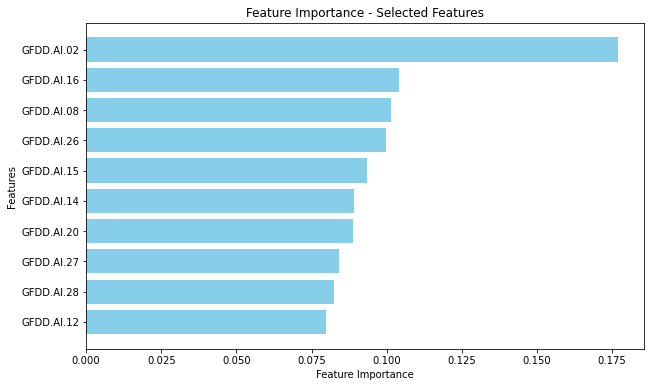

In [45]:
# Get feature importances from the trained model
feature_importances = rf_RFE.feature_importances_

# Create a DataFrame for feature importance
feature_importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': feature_importances
})

# Sort features by importance
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance - Selected Features')
plt.gca().invert_yaxis()
plt.show()